#Imports and setups

In [ ]:
!pip install ultralytics opencv-python pycocotools
import os, shutil
import json, cv2
import pandas as pd
import requests
import random
from tqdm import tqdm
from collections import defaultdict
from ultralytics import YOLO
import torch
!pip install segmentation_models_pytorch
from segmentation_models_pytorch import Unet
import numpy as np
from torch.serialization import save
from enum import auto
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.8 MB/s eta 0:00:00


#Training

In [ ]:
if torch.cuda.is_available():
    print("GPU is available! You can enable GPU training.")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available. Training will continue on CPU.")

In [3]:
#Copy and move TACO dataset. Only needed once if on personal drive
!git clone https://github.com/pedropro/TACO.git
#!mv TACO /content/drive/MyDrive/Colab\ Notebooks

Cloning into 'TACO'...
remote: Enumerating objects: 740, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 740 (delta 416), reused 380 (delta 380), pack-reused 305 (from 1)
Receiving objects: 100% (740/740), 97.48 MiB | 10.19 MiB/s, done.
Resolving deltas: 100% (499/499), done.


In [18]:
'''
#Try multithreading?
Image download,
Conversion of TACO labels for YOLO.
TACO use coco JSON format
'''
debug = False
TACO_path = "/content/TACO/data" #drive/MyDrive/Colab Notebooks/TACO/data"

with open(os.path.join(TACO_path, "annotations.json")) as f:
    data = json.load(f)

lbl_output_dir = "/content/TACO_yolo/labels" #'/content/drive/MyDrive/Colab Notebooks/TACO_yolo/labels'
img_output_dir = "/content/TACO_yolo/images"
mask_output_dir = "/content/TACO_yolo/masks"

os.makedirs(os.path.join(img_output_dir,"all_images"), exist_ok=True)
os.makedirs(os.path.join(img_output_dir,"crops"), exist_ok=True)
os.makedirs(os.path.join(lbl_output_dir,"all_labels"), exist_ok=True)
os.makedirs(os.path.join(mask_output_dir,"crops"), exist_ok=True)

#iterate through all images in dataset and add to list
images = {img["id"]: img for img in data["images"]}

"""Get images"""

image_to_annotations = defaultdict(list)

for ann in data["annotations"]:
    image_to_annotations[ann["image_id"]].append(ann)

for img_id, img in tqdm(images.items()):
    #file_name = img["file_name"].split("/")[-1]
    file_name = f"{img_id}"
    url = img.get("flickr_640_url") or img.get("flickr_url")


    if not url:
        continue

    img_save_path = os.path.join(img_output_dir,"all_images", f'{file_name}.jpg')
    lbl_save_path = os.path.join(lbl_output_dir,"all_labels", f'{file_name}.txt')
    mask_save_path = os.path.join(mask_output_dir,"all_masks", f'{file_name}.png')
    #image
    if not os.path.exists(img_save_path):
      try:
          response = requests.get(url, timeout=10)

          with open(img_save_path, 'wb') as f:
              f.write(response.content)

      except:
          print(f"Failed image: {file_name}")
          continue

    image = cv2.imread(img_save_path)
    # width = img["width"]
    # height = img["height"]
    height, width, _ = image.shape

    # print("Original:", img["width"], img["height"])
    # print("Actual:", image.shape[1], image.shape[0])
    #labels

    scale_x = width / img["width"]
    scale_y = height / img["height"]

    import matplotlib.pyplot as plt

    #label & masks
    anns = image_to_annotations[img_id]
    mask = np.zeros((height, width), dtype=np.uint8)

    label_lines = []

    for i, ann in enumerate(anns): # Added enumerate to get index 'i'
        x, y, w, h = ann["bbox"]

        x *= scale_x
        y *= scale_y
        w *= scale_x
        h *= scale_y

        x_center = (x + w/2) / width
        y_center = (y + h/2) / height
        w_norm = w / width
        h_norm = h / height

        label_lines.append(f"0 {x_center} {y_center} {w_norm} {h_norm}")
        #seg starts
        segmentation_data = ann["segmentation"]
        if isinstance(segmentation_data, list): #check if it is a list. no data would lead to no list!
            polygons_to_fill = []
            if all(isinstance(p, list) for p in segmentation_data): #is each elements a list or actual coordinates
                for poly_coords in segmentation_data:
                    if poly_coords:
                        pts = np.array(poly_coords).reshape(-1, 2).astype(np.float32)
                        pts[:, 0] *= scale_x
                        pts[:, 1] *= scale_y
                        pts = pts.astype(np.int32)
                        polygons_to_fill.append(pts)
            elif segmentation_data: # It's a single polygon
                pts = np.array(poly_coords).reshape(-1, 2).astype(np.float32)
                pts[:, 0] *= scale_x
                pts[:, 1] *= scale_y
                pts = pts.astype(np.int32)
                polygons_to_fill.append(pts)

            if polygons_to_fill:
                cv2.fillPoly(mask, polygons_to_fill, 1)

        #Unet short clips
        x1, y1 = int(x), int(y)
        x2, y2 = int(x + w), int(y + h)

        # padding
        pad = 0.1
        x_pad, y_pad = int(pad*w), int(pad*h)

        #clipping
        x1 = max(0, x1 - x_pad)
        y1 = max(0, y1 - y_pad)
        x2 = min(width, x2 + x_pad)
        y2 = min(height, y2 + y_pad)

        #cropping
        img_crop = image[y1:y2, x1:x2]
        mask_crop = mask[y1:y2, x1:x2]

        if img_crop.size > 0 and debug == True:
          # Convert image to RGB for display
          display_img = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)

          plt.figure(figsize=(12, 4))

          # Cropped Image
          plt.subplot(1, 3, 1)
          plt.imshow(display_img)
          plt.title(f"Crop: {file_name}_{i}")
          plt.axis('off')

          # Mask
          plt.subplot(1, 3, 2)
          plt.imshow(mask_crop, cmap='gray')
          plt.title("Mask")
          plt.axis('off')

          # Overlay
          plt.subplot(1, 3, 3)
          plt.imshow(display_img)
          plt.imshow(mask_crop, cmap='jet', alpha=0.4)
          plt.title("Overlay")
          plt.axis('off')

          plt.tight_layout()
          plt.show()

          input("Press Enter to continue...")

        # skip empty crops
        if img_crop.size == 0:
          continue

        crop_id = f"{file_name}_{i}"

        cv2.imwrite(f"{img_output_dir}/crops/{crop_id}.jpg", img_crop)
        cv2.imwrite(f"{mask_output_dir}/crops/{crop_id}.png", mask_crop)

    # Write label file
    with open(lbl_save_path, 'w') as f:
        f.write("\n".join(label_lines))

    #write masks
    #if not os.path.exists(mask_save_path) and np.any(mask): # Only save if the mask is not entirely empty
    #  cv2.imwrite(mask_save_path, mask)

100%|██████████| 1500/1500 [17:43<00:00,  1.41it/s]


In [ ]:
for labels in os.listdir(os.path.join(lbl_output_dir,"all_labels")):
  for label_line in open(os.path.join(lbl_output_dir,"all_labels", labels)):


In [24]:
"""dataset split"""

images = [f for f in os.listdir(os.path.join(img_output_dir,"all_images")) if f.endswith(".jpg")]

random.shuffle(images)

split_ratio = 0.8
split_index = int(len(images) * split_ratio)

train_images = images[:split_index]
val_images = images[split_index:]

# Create train and val subdirectories inside img_output_dir and lbl_output_dir + segmen
os.makedirs(os.path.join(img_output_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(img_output_dir, "val"), exist_ok=True)
os.makedirs(os.path.join(lbl_output_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(lbl_output_dir, "val"), exist_ok=True)
os.makedirs(os.path.join(mask_output_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(mask_output_dir, "val"), exist_ok=True)



for img in train_images:
  label = img.replace(".jpg", ".txt")
  mask = img.replace(".jpg", ".png")
  shutil.copy(os.path.join(img_output_dir,"all_images", img),
              os.path.join(img_output_dir, "train", img))
  shutil.copy(os.path.join(lbl_output_dir,"all_labels", label),
              os.path.join(lbl_output_dir, "train", label))
  # shutil.copy(os.path.join(mask_output_dir,"all_masks",mask),
  #             os.path.join(mask_output_dir, "train", mask))

for img in val_images:
  label = img.replace(".jpg", ".txt")
  mask = img.replace(".jpg", ".png")
  shutil.copy(os.path.join(img_output_dir,"all_images", img),
              os.path.join(img_output_dir, "val", img))
  shutil.copy(os.path.join(lbl_output_dir,"all_labels", label),
              os.path.join(lbl_output_dir, "val", label))
  # shutil.copy(os.path.join(mask_output_dir,"all_masks",mask),
  #             os.path.join(mask_output_dir, "val", mask))

In [25]:
#YAML file for training

yaml_content = """
path: /content/TACO_yolo

train: images/train
val: images/val

names:
  0: trash
"""

with open('/content/trash.yaml', 'w') as f:
    f.write(yaml_content)

In [26]:

model = YOLO("yolov8n.pt")

if torch.cuda.is_available():
    device = 0  # Use the first available GPU
else:
    device = 'cpu' # Fallback to CPU if no GPU is available

model.train(
    data="/content/trash.yaml",
    epochs=100,
    imgsz=640,
    batch=-1,
    device=device,
    #patience = 5,
    box = True,
    resume = True,
    cache = True,
    save_period = 10)     #save default true, optimizer auto, lr0=0.01, mome 0.937, val true, plots true

WARNING ⚠️ model 'yolov8n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=True, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ee58aa9c170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [27]:
model.save('/content/drive/MyDrive/Colab Notebooks/Final_project/yolo_trash_model.pt3')

In [28]:
source_dir = '/content/runs/detect/train'

destination_dir = '/content/drive/MyDrive/Colab Notebooks/Final_project/yolo_training_results3'

# Ensure the source directory exists
if not os.path.exists(source_dir):
    print(f"Error: Source directory '{source_dir}' does not exist.")
else:
    # Create the destination directory if it doesn't exist, or remove it
    if os.path.exists(destination_dir):
        print(f"Warning: Destination directory '{destination_dir}' already exists. Removing its contents...")
        shutil.rmtree(destination_dir)

    print(f"Copying training results from '{source_dir}' to '{destination_dir}'...")
    shutil.copytree(source_dir, destination_dir)
    print("Copying complete!")

Copying training results from '/content/runs/detect/train' to '/content/drive/MyDrive/Colab Notebooks/Final_project/yolo_training_results3'...
Copying complete!


Train U_net

In [29]:


class TacoDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        # Normalize
        image = image / 255.0
        mask = (mask > 0).astype("float32")  # binary mask

        # To tensor
        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottom = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bottom(self.pool3(d3))

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)


train_dataset = TacoDataset(
    img_dir="/content/TACO_yolo/images/crops",
    mask_dir="/content/TACO_yolo/masks/crops"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)


In [30]:
U_model = UNet().cuda()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(u_model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    u_model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.cuda()
        masks = masks.cuda()

        preds = u_model(imgs)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.5407
Epoch 2, Loss: 0.4760
Epoch 3, Loss: 0.4672
Epoch 4, Loss: 0.4617
Epoch 5, Loss: 0.4499
Epoch 6, Loss: 0.4353
Epoch 7, Loss: 0.4213
Epoch 8, Loss: 0.4099
Epoch 9, Loss: 0.4003
Epoch 10, Loss: 0.3925


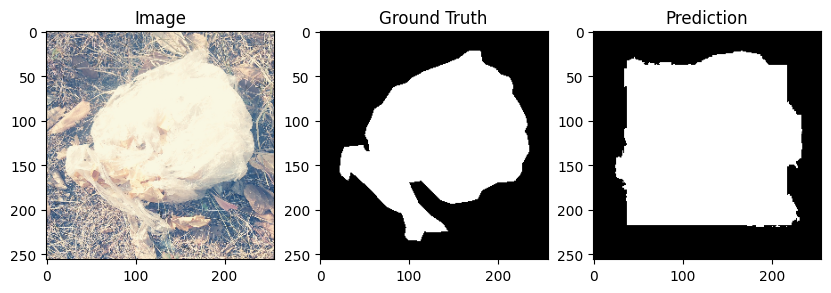

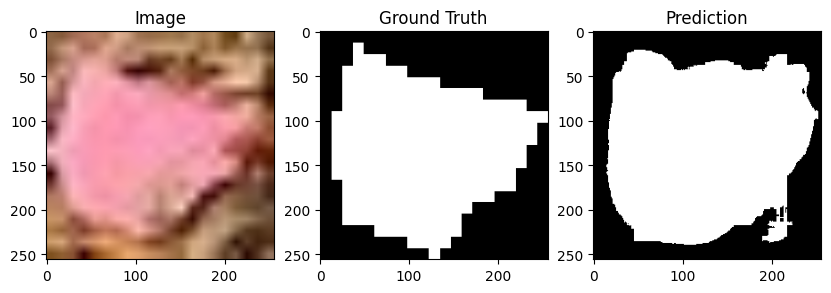

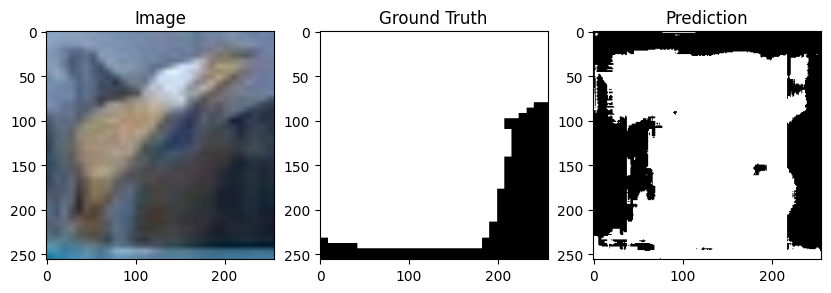

In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

u_model.eval()
with torch.no_grad():
    imgs, masks = next(iter(train_loader))
    imgs = imgs.cuda()

    preds = model(imgs)
    preds = torch.sigmoid(preds)

    for i in range(3):
        plt.figure(figsize=(10,3))

        # Image
        plt.subplot(1,3,1)
        plt.imshow(imgs[i].cpu().permute(1,2,0))
        plt.title("Image")

        # GT Mask
        plt.subplot(1,3,2)
        plt.imshow(masks[i][0], cmap='gray')
        plt.title("Ground Truth")

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(preds[i][0].cpu() > 0.5, cmap='gray')
        plt.title("Prediction")

        plt.show()

#Runs

In [ ]:
#Video to image


In [ ]:
model = YOLO('/content/drive/MyDrive/Colab Notebooks/yolo_trash_model.pt') #load existing weight


model.eval()
unet_model.eval()

yolo_results = model(image)

result = yolo_results[0]
bboxes = result.boxes.xyxy.cpu().numpy()
confidences = result.boxes.conf.cpu().numpy()

bboxes = results.bboxes.cpu().numpy()
confidences = resconfidences.cpu().numpy()

cropped_images = []

for bbox, confidence in zip(bboxes, confidences):
  if confidence < 0.5:
    continue

  x1, y1, x2, y2 = map(int, bbox) #bbox format?
  cropped_image = image[y1:y2, x1:x2]

  cropped_images.append({"img": cropped_image,
                         "bbox": (x1, y1, x2, y2) })
for image in cropped_images:
  img = image["img"]
  bbox = image["bbox"]



segmented_outputs = []

for item in cropped_images:
    crop = item["img"]
    bbox = item["bbox"]

    input_tensor = preprocess(crop)

    with torch.no_grad():
        pred = unet_model(input_tensor)
        pred = torch.sigmoid(pred)

    mask = pred[0, 0].cpu().numpy()
    mask = (mask > 0.5).astype(np.uint8)

    # Resize mask back to crop size
    mask = cv2.resize(mask, (crop.shape[1], crop.shape[0]),
                      interpolation=cv2.INTER_NEAREST)

    segmented_outputs.append({
        "mask": mask,
        "bbox": bbox
    })